In [2]:
from __future__ import print_function, division
import sys,os
# line 4 and line 5 below are for development purposes and ca be removed
qspin_path = os.path.join(os.getcwd(),"../../")
sys.path.insert(0,qspin_path)
from quspin.operators import hamiltonian # Hamiltonians and operators
#from quspin.basis import spinless_fermion_basis_1d # Hilbert space fermion basis
from quspin.basis import spin_basis_1d # Hilbert space spin basis
import numpy as np # generic math functions
import matplotlib.pyplot as plt # plotting library
from scipy.linalg import expm, sinm, cosm
from numpy.linalg import multi_dot
from scipy.sparse import csr_matrix, csc_matrix, coo_matrix, lil_matrix
from scipy.sparse.linalg import inv, eigs
from scipy.linalg import svdvals
from scipy.stats import unitary_group
from scipy import linalg
from numpy import linalg as LA
import pylab
import time
import numba
from numba import njit,c16,i8,u2
import sys
import math

np.set_printoptions(precision=2)
np.set_printoptions(suppress=True)
np.set_printoptions(threshold=np.inf, linewidth=np.inf)

time_sta = time.time()

####################################################
def initial_stabilizer_state(Ld,Lxd,Lyd,v_ind,p_ind):
    # Ld: total # of qubits
    MRi=np.zeros((Ld,2*Ld),dtype='uint32')
    #Case I: X product state
    for ii in range(Ld):
        MRi[ii][ii]=1 # X     
    ##Case II: unique g.s. of TC 
    ### plaquette stabilizers ZZZ ###
#    for ip in range(2*Lxd*Lyd-1):
#        MRi[ip][Ld+p_ind[ip][0]]=1 # Z0
#        MRi[ip][Ld+p_ind[ip][1]]=1 # Z1
#        MRi[ip][Ld+p_ind[ip][2]]=1 # Z2
        #独立ではない最後のBpだけ取らない
    ### vertex stabilizers  XXXXXX ###
#    for iv in range((Lxd)*(Lyd)-1):
#        ivs=iv+2*Lxd*Lyd-1  # note that iv and ivs are different.
#        MRi[ivs][v_ind[iv][0]]=1 # X0
#        MRi[ivs][v_ind[iv][1]]=1 # X1
#        MRi[ivs][v_ind[iv][2]]=1 # X2
#        MRi[ivs][v_ind[iv][3]]=1 # X3
#        MRi[ivs][v_ind[iv][4]]=1 # X4
#        MRi[ivs][v_ind[iv][5]]=1 # X5
        #独立ではない最後のAvだけ取らない
    ### Add logical operators###
    # x-direction loop logical Z
#    for kk in range(Lx):
#        iv=(kk%Lx)+Lx*(0%Ly)
#        MRi[Ld-2][Ld+v_ind[iv][0]]=1 #Z
    # x-direction loop logical Z
#    for kk in range(Ly):
#        iv=(0%Lx)+Lx*(kk%Ly)
#        MRi[Ld-1][Ld+v_ind[iv][1]]=1 #Z
    return MRi

####################################################
def measurement_op(dMR,Ld,Lxd,Lyd,v_ind,p_ind,Gcd,mtyped):
    Meo=np.zeros(2*Ld,dtype='uint32')
    #
    if mtyped==1: #plaquette or star operator
        todo=[0,1]
        prob_list = [0.5,0.5]
        vorp = np.random.choice(todo,size=None,replace=True, p=prob_list)
        if vorp==0:
            todo=np.arange(Lxd*Lyd)
            vp=np.random.choice(todo,size=None,replace=True,p=None)
            #please check
            Meo[v_ind[vp][0]]=1 #X0
            Meo[v_ind[vp][1]]=1 #X1
            Meo[v_ind[vp][2]]=1 #X2
            Meo[v_ind[vp][3]]=1 #X3
            Meo[v_ind[vp][4]]=1 #X4
            Meo[v_ind[vp][5]]=1 #X5
        else:
            todo=np.arange(2*Lxd*Lyd)
            pp=np.random.choice(todo,size=None,replace=True,p=None)
            #please check
            Meo[Ld+p_ind[pp][0]]=1 #Z0
            Meo[Ld+p_ind[pp][1]]=1 #Z1
            Meo[Ld+p_ind[pp][2]]=1 #Z2
            
    if mtyped==2: #local X
        todo=np.arange(Ld)
        mp=np.random.choice(todo,size=None,replace=True,p=None)
        #please check
        Meo[mp]=1 #X0
        
    if mtyped==3: #local Z
        todo=np.arange(Ld)
        mp=np.random.choice(todo,size=None,replace=True,p=None)
        #please check
        Meo[Ld+mp]=1 #X0
    
    # Meo without outcome sign
    MeoF=np.zeros(2*Ld,dtype='uint32')
    MeoF=Meo
    
    # dMR without foctor
    dMRF=np.zeros((Ld,2*Ld),dtype='uint32')
    dMRF=dMR
    #check anti commtation
    Mgs=np.dot(dMRF,np.dot(Gcd,MeoF.T))
    Mgs=Mgs%2  ## check: reduce Z2 value 
    
    antic_index_list=[]
    aid=np.where(Mgs[:]!=0)
    antic_index_list=aid[0]
    #######
    lenMe=len(antic_index_list)
    if lenMe !=0:
        kc=antic_index_list[0]
        dMR_prev=dMR[kc].copy()
        #replace stabilizer for kc
        dMR[kc]=Meo
        update_list=np.delete(antic_index_list,0)
        dMR[update_list,:]=np.mod(dMR[update_list,:]+dMR_prev,2)
    return dMR

####################
#EE
####################
# https://arxiv.org/abs/2204.08489
def TMI_cal(MRFd,Ld):
    # partition #
    # A: upper rough boundary sites
    LA=Lx #SAF
    MRdA=np.zeros((Ld,2*(LA)),dtype='uint32')
    #Create trancated matrix
    #A
    for k2 in range(LA):
        MRdA[:,k2]=MRFd[:,k2].copy()
        MRdA[:,(LA)+k2]=MRFd[:,(Ld)+k2].copy()
    rankA=rank_mod2_v3(MRdA)
    SA=rankA-(LA)
    TMI3=SA
    #TMI3 = (SA+SB+SC+SD-SAB-SAC-SBC)/(0.69314)
    return TMI3

#############################
def rank_mod2_v3(MRdd):
    # MRdA construct
    i = 0
    Ic = MRdd.shape[0]
    Jc = MRdd.shape[1]
    for j in range(Jc):
        check_ind=np.where(MRdd[i:,j]==1)
        if len(check_ind[0]) !=0:
            if len(check_ind[0]) >1:
                elim_ind=np.delete(check_ind,0)
                MRdd[elim_ind+i,:]=np.mod(MRdd[elim_ind+i,:]+MRdd[check_ind[0][0]+i,:],2)
            MRdd[i,:],MRdd[check_ind[0][0]+i,:] = MRdd[check_ind[0][0]+i,:],MRdd[i,:].copy()
            i=i+1
    return i
############################

### Main part ###
## triangular lattice under PBC##
#set the vertex lattice system size 
Lx=3
Ly=3

Lv=Lx*Ly # total # of vertex
L=3*Lv # total # of link qubits
Lp=2*Lv  # total # of plaquette

###############################################
# Create 3-directed edge index for each vertex
#Lx,Ly= 2,2  # vertex格子サイズ
###############################################
#v_3e_indd = np.zeros((Lx*Ly,3),dtype='uint32')
def idx(x, y):
    return (x % Lx)+Lx*(y % Ly)
def inv_idx(i):
    return i % Lx, i // Lx
# 方向 0: (x+1, y), 1: (x, y+1), 2: (x-1, y+1)
directions = [(+1, 0), (0, +1), (+1, +1)]
# 一意な辺のリスト（方向0,1,2のみ使って構築）
edge_set = set()
for y in range(Ly):
    for x in range(Lx):
        i = idx(x, y)
        for dx, dy in directions:
            j = idx(x + dx, y + dy)
            edge = tuple(sorted((i, j)))
            edge_set.add(edge)
# 辞書順に並べてedge indexを定義
sorted_edges = sorted(edge_set)
edge_to_index = {e: n for n, e in enumerate(sorted_edges)}

####################################
# 関数：vertex index i に対して方向 0, 1, 2 の edge_index を返す
def get_3edge_indices_from_vertex(i):
    x, y = inv_idx(i)
    indices = []
    for dx, dy in directions:
        j = idx(x + dx, y + dy)
        edge = tuple(sorted((i, j)))
        indices.append(edge_to_index[edge])
    return indices
####################################
# Create vertex operator edge-labels
v_e_indd = np.zeros((Lx*Ly,6),dtype='uint32')
for iy in range(Ly):
    for ix in range(Lx):
        ic=(ix%Lx)+Lx*(iy%Ly)
        icmx=((ix-1)%Lx)+Lx*(iy%Ly)
        icmy=((ix)%Lx)+Lx*((iy-1)%Ly)
        icpxmy=((ix+1)%Lx)+Lx*((iy-1)%Ly)       
        v_e_indd[ic][0]=get_3edge_indices_from_vertex(ic)[0]
        v_e_indd[ic][1]=get_3edge_indices_from_vertex(ic)[1]
        v_e_indd[ic][2]=get_3edge_indices_from_vertex(ic)[2]
        v_e_indd[ic][3]=get_3edge_indices_from_vertex(icmx)[0]
        v_e_indd[ic][4]=get_3edge_indices_from_vertex(icmy)[1]
        v_e_indd[ic][5]=get_3edge_indices_from_vertex(icpxmy)[2]
#######################################
# Create plaquette operator edge-labels
p_e_indd = np.zeros((2*Lx*Ly,3),dtype='uint32')
for iy in range(Ly):
    for ix in range(Lx):
        #上三角
        ic=(ix%Lx)+Lx*(iy%Ly)
        icpx=((ix+1)%Lx)+Lx*(iy%Ly)
        p_e_indd[ic][0]=get_3edge_indices_from_vertex(ic)[0]
        p_e_indd[ic][1]=get_3edge_indices_from_vertex(icpx)[2]
        p_e_indd[ic][2]=get_3edge_indices_from_vertex(ic)[1]
        #下三角
        ic=(ix%Lx)+Lx*(iy%Ly)
        icpy=((ix)%Lx)+Lx*((iy+1)%Ly)
        p_e_indd[ic+Lx*Ly][0]=get_3edge_indices_from_vertex(icpx)[1]
        p_e_indd[ic+Lx*Ly][1]=get_3edge_indices_from_vertex(icpy)[0]
        p_e_indd[ic+Lx*Ly][2]=get_3edge_indices_from_vertex(icpx)[2]
### check matrix ###
Gc=np.zeros((2*L,2*L),dtype='uint32') # 2L * 2L matrix
for k in range(L):
    Gc[k][L+k]=1
    Gc[L+k][k]=1  
Gc_csr=csr_matrix(Gc)

### Main part ###
Nd = 3 # sample number
#for ip in range(len(p_list)):
pg=0.1   #p_list[ip]
px=0.3
pz=1-pg-px

# stabilizer matrix
MR=np.zeros((L,2*L),dtype='uint32') # L * 2L matrix

# sample set of physical quantity
PQ=[]
MR0=initial_stabilizer_state(L,Lx,Ly,v_e_indd,p_e_indd)#
print(MR0)
for ids in range(Nd):
    MR=MR0 
    #measurement dynamics
    NT=4 # total time step
    prob_list=[pg,px,pz]
    todo=[1,2,3]
    for it in range(int(NT)):
        mtype= np.random.choice(todo,size=None,replace=True,p=prob_list)
        MR=measurement_op(MR,L,Lx,Ly,v_e_indd,p_e_indd,Gc,mtype)
        PQ=+TMI_cal(MR,L)
        print(ids,it,PQ)

[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 

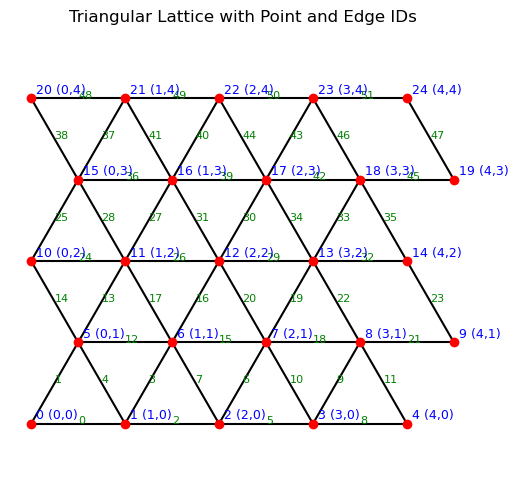

In [80]:
import matplotlib.pyplot as plt
import numpy as np

Lx, Ly = 5, 5  # 格子サイズ

# 格子点の座標と通し番号を作成
points = []
xy_labels = []
for y in range(Ly):
    for x in range(Lx):
        px = x + 0.5 * (y % 2)
        py = y * np.sqrt(3) / 2
        idx = y * Lx + x
        points.append({'id': idx, 'x': px, 'y': py, 'grid_x': x, 'grid_y': y})

# 隣接リンク（エッジ）と通し番号を作成
edges = []
edge_id = 0
for y in range(Ly):
    for x in range(Lx):
        i = y * Lx + x
        # 右
        if x < Lx - 1:
            j = y * Lx + (x + 1)
            edges.append({'id': edge_id, 'from': i, 'to': j})
            edge_id += 1
        # 右上
        if (y < Ly - 1) and (x + (y % 2) < Lx - 1):
            j = (y + 1) * Lx + (x + (y % 2))
            edges.append({'id': edge_id, 'from': i, 'to': j})
            edge_id += 1
        # 左上
        if (y < Ly - 1) and (x + (y % 2) - 1 >= 0):
            j = (y + 1) * Lx + (x + (y % 2) - 1)
            edges.append({'id': edge_id, 'from': i, 'to': j})
            edge_id += 1

# プロット
plt.figure(figsize=(6, 6))
for edge in edges:
    i, j = edge['from'], edge['to']
    x0, y0 = points[i]['x'], points[i]['y']
    x1, y1 = points[j]['x'], points[j]['y']
    plt.plot([x0, x1], [y0, y1], 'k-')
    # エッジ番号をエッジの中点に表示
    mx, my = (x0 + x1) / 2, (y0 + y1) / 2
    plt.text(mx, my, f"{edge['id']}", fontsize=8, color='green')

for pt in points:
    plt.plot(pt['x'], pt['y'], 'ro')
    # 点の通し番号と格子座標を表示
    plt.text(pt['x'] + 0.05, pt['y'] + 0.05, f"{pt['id']} ({pt['grid_x']},{pt['grid_y']})", fontsize=9, color='blue')

plt.axis('equal')
plt.axis('off')
plt.title("Triangular Lattice with Point and Edge IDs")
plt.show()

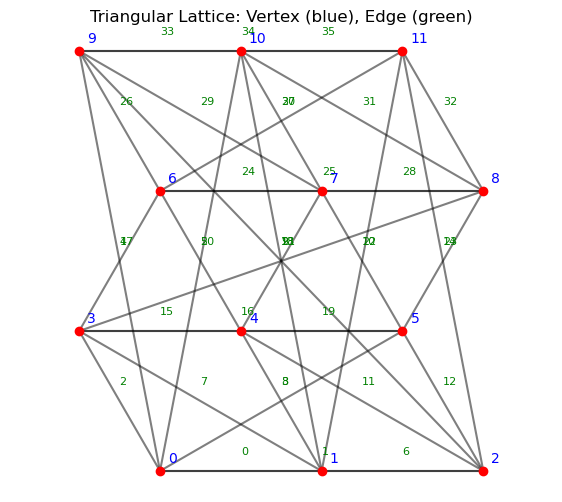

v_e_indd (vertexごとの6本のエッジインデックス):
vertex 0: [0 2 3 1 4 5]
vertex 1: [ 6  8  7  0  9 10]
vertex 2: [ 1 12 11  6 14 13]
vertex 3: [15 17 18 16  2  7]
vertex 4: [19 21 20 15  8 11]
vertex 5: [16 23 22 19 12  3]
vertex 6: [24 26 27 25 17 20]
vertex 7: [28 30 29 24 21 22]
vertex 8: [25 32 31 28 23 18]
vertex 9: [33  4 13 34 26 29]
vertex 10: [35  9  5 33 30 31]
vertex 11: [34 14 10 35 32 27]

p_e_indd (三角形ごとの3本のエッジインデックス):
triangle 0: [0 7 2]
triangle 1: [ 6 11  8]
triangle 2: [ 1  3 12]
triangle 3: [15 20 17]
triangle 4: [19 22 21]
triangle 5: [16 18 23]
triangle 6: [24 29 26]
triangle 7: [28 31 30]
triangle 8: [25 27 32]
triangle 9: [33  5  4]
triangle 10: [35 10  9]
triangle 11: [34 13 14]
triangle 12: [ 8 15  7]
triangle 13: [12 19 11]
triangle 14: [ 2 16  3]
triangle 15: [21 24 20]
triangle 16: [23 28 22]
triangle 17: [17 25 18]
triangle 18: [30 33 29]
triangle 19: [32 35 31]
triangle 20: [26 34 27]
triangle 21: [9 0 5]
triangle 22: [14  6 10]
triangle 23: [ 4  1 13]


In [91]:
import numpy as np
import matplotlib.pyplot as plt

Lx, Ly = 3, 4  # vertex格子サイズ

# 格子点の座標
def idx(x, y):
    return (x % Lx) + Lx * (y % Ly)
def inv_idx(i):
    return i % Lx, i // Lx

# 方向 0: (x+1, y), 1: (x, y+1), 2: (x-1, y+1)
directions = [(+1, 0), (0, +1), (-1, +1)]

# 一意な辺のリスト（方向0,1,2のみ使って構築）
edge_set = set()
for y in range(Ly):
    for x in range(Lx):
        i = idx(x, y)
        for dx, dy in directions:
            j = idx(x + dx, y + dy)
            edge = tuple(sorted((i, j)))
            edge_set.add(edge)
sorted_edges = sorted(edge_set)
edge_to_index = {e: n for n, e in enumerate(sorted_edges)}

# 関数：vertex index i に対して方向0,1,2の edge_index を返す
def get_3edge_indices_from_vertex(i):
    x, y = inv_idx(i)
    indices = []
    for dx, dy in directions:
        j = idx(x + dx, y + dy)
        edge = tuple(sorted((i, j)))
        indices.append(edge_to_index[edge])
    return indices

# 頂点座標リスト
points = []
for y in range(Ly):
    for x in range(Lx):
        px = x + 0.5 * ((y+1) % 2)
        py = y * np.sqrt(3) / 2
        points.append((px, py))

# エッジ座標リスト
edges = []
for e, (i, j) in enumerate(sorted_edges):
    x0, y0 = points[i]
    x1, y1 = points[j]
    edges.append({'id': e, 'from': i, 'to': j, 'x0': x0, 'y0': y0, 'x1': x1, 'y1': y1})

# v_e_indd, p_e_inddの構築
v_e_indd = np.zeros((Lx*Ly,6), dtype='uint32')
for iy in range(Ly):
    for ix in range(Lx):
        ic = idx(ix, iy)
        icmx = idx(ix-1, iy)
        icmy = idx(ix, iy-1)
        icpxmy = idx(ix+1, iy-1)
        v_e_indd[ic][0] = get_3edge_indices_from_vertex(ic)[0]
        v_e_indd[ic][1] = get_3edge_indices_from_vertex(ic)[1]
        v_e_indd[ic][2] = get_3edge_indices_from_vertex(ic)[2]
        v_e_indd[ic][3] = get_3edge_indices_from_vertex(icmx)[0]
        v_e_indd[ic][4] = get_3edge_indices_from_vertex(icmy)[1]
        v_e_indd[ic][5] = get_3edge_indices_from_vertex(icpxmy)[2]

p_e_indd = np.zeros((2*Lx*Ly,3), dtype='uint32')
for iy in range(Ly):
    for ix in range(Lx):
        # 上三角
        ic = idx(ix, iy)
        icpx = idx(ix+1, iy)
        p_e_indd[ic][0] = get_3edge_indices_from_vertex(ic)[0]
        p_e_indd[ic][1] = get_3edge_indices_from_vertex(icpx)[2]
        p_e_indd[ic][2] = get_3edge_indices_from_vertex(ic)[1]
        # 下三角
        icpy = idx(ix, iy+1)
        p_e_indd[ic+Lx*Ly][0] = get_3edge_indices_from_vertex(icpx)[1]
        p_e_indd[ic+Lx*Ly][1] = get_3edge_indices_from_vertex(icpy)[0]
        p_e_indd[ic+Lx*Ly][2] = get_3edge_indices_from_vertex(icpx)[2]

# 可視化
plt.figure(figsize=(7, 6))
# エッジ描画
for edge in edges:
    plt.plot([edge['x0'], edge['x1']], [edge['y0'], edge['y1']], 'k-', alpha=0.5)
    mx, my = (edge['x0'] + edge['x1'])/2, (edge['y0'] + edge['y1'])/2+0.1
    plt.text(mx, my, f"{edge['id']}", color='green', fontsize=8)

# 頂点描画
for i, (x, y) in enumerate(points):
    plt.plot(x, y, 'ro')
    plt.text(x+0.05, y+0.05, f"{i}", color='blue', fontsize=10)

plt.axis('equal')
plt.axis('off')
plt.title("Triangular Lattice: Vertex (blue), Edge (green)")
plt.show()

# v_e_indd, p_e_inddの内容を表示
print("v_e_indd (vertexごとの6本のエッジインデックス):")
for i in range(Lx*Ly):
    print(f"vertex {i}: {v_e_indd[i]}")

print("\np_e_indd (三角形ごとの3本のエッジインデックス):")
for i in range(2*Lx*Ly):
    print(f"triangle {i}: {p_e_indd[i]}")

In [92]:
import numpy as np

Lx, Ly = 3, 4  # vertex格子サイズ

def idx(x, y):
    return (x % Lx) + Lx * (y % Ly)

def inv_idx(i):
    return i % Lx, i // Lx

# 方向 0: (x+1, y), 1: (x, y+1), 2: (x-1, y+1)
directions = [(+1, 0), (0, +1), (-1, +1)]

# 一意な辺のリスト（周期境界）
edge_set = set()
for y in range(Ly):
    for x in range(Lx):
        i = idx(x, y)
        for dx, dy in directions:
            j = idx(x + dx, y + dy)
            edge = tuple(sorted((i, j)))
            edge_set.add(edge)
sorted_edges = sorted(edge_set)
edge_to_index = {e: n for n, e in enumerate(sorted_edges)}

# 関数：vertex index i に対して方向0,1,2の edge_index を返す
def get_3edge_indices_from_vertex(i):
    x, y = inv_idx(i)
    indices = []
    for dx, dy in directions:
        j = idx(x + dx, y + dy)
        edge = tuple(sorted((i, j)))
        indices.append(edge_to_index[edge])
    return indices

# 頂点ごとの6本のエッジインデックス
v_e_indd = np.zeros((Lx*Ly, 6), dtype='uint32')
for iy in range(Ly):
    for ix in range(Lx):
        ic = idx(ix, iy)
        icmx = idx(ix-1, iy)
        icmy = idx(ix, iy-1)
        icpxmy = idx(ix+1, iy-1)
        v_e_indd[ic][0] = get_3edge_indices_from_vertex(ic)[0]
        v_e_indd[ic][1] = get_3edge_indices_from_vertex(ic)[1]
        v_e_indd[ic][2] = get_3edge_indices_from_vertex(ic)[2]
        v_e_indd[ic][3] = get_3edge_indices_from_vertex(icmx)[0]
        v_e_indd[ic][4] = get_3edge_indices_from_vertex(icmy)[1]
        v_e_indd[ic][5] = get_3edge_indices_from_vertex(icpxmy)[2]
        print(f"vertex ({ix},{iy}) idx={ic} : {v_e_indd[ic]}")

# 三角形ごとの3本のエッジインデックス
p_e_indd = np.zeros((2*Lx*Ly, 3), dtype='uint32')
for iy in range(Ly):
    for ix in range(Lx):
        # 上三角
        ic = idx(ix, iy)
        icpx = idx(ix+1, iy)
        p_e_indd[ic][0] = get_3edge_indices_from_vertex(ic)[0]
        p_e_indd[ic][1] = get_3edge_indices_from_vertex(icpx)[2]
        p_e_indd[ic][2] = get_3edge_indices_from_vertex(ic)[1]
        # 下三角
        icpy = idx(ix, iy+1)
        p_e_indd[ic+Lx*Ly][0] = get_3edge_indices_from_vertex(icpx)[1]
        p_e_indd[ic+Lx*Ly][1] = get_3edge_indices_from_vertex(icpy)[0]
        p_e_indd[ic+Lx*Ly][2] = get_3edge_indices_from_vertex(icpx)[2]
        print(f"triangle upper ({ix},{iy}) idx={ic} : {p_e_indd[ic]}")
        print(f"triangle lower ({ix},{iy}) idx={ic+Lx*Ly} : {p_e_indd[ic+Lx*Ly]}")

# エッジリストも表示
print("\nEdge index list (sorted_edges):")
for n, e in enumerate(sorted_edges):
    print(f"edge {n}: {e}")

vertex (0,0) idx=0 : [0 2 3 1 4 5]
vertex (1,0) idx=1 : [ 6  8  7  0  9 10]
vertex (2,0) idx=2 : [ 1 12 11  6 14 13]
vertex (0,1) idx=3 : [15 17 18 16  2  7]
vertex (1,1) idx=4 : [19 21 20 15  8 11]
vertex (2,1) idx=5 : [16 23 22 19 12  3]
vertex (0,2) idx=6 : [24 26 27 25 17 20]
vertex (1,2) idx=7 : [28 30 29 24 21 22]
vertex (2,2) idx=8 : [25 32 31 28 23 18]
vertex (0,3) idx=9 : [33  4 13 34 26 29]
vertex (1,3) idx=10 : [35  9  5 33 30 31]
vertex (2,3) idx=11 : [34 14 10 35 32 27]
triangle upper (0,0) idx=0 : [0 7 2]
triangle lower (0,0) idx=12 : [ 8 15  7]
triangle upper (1,0) idx=1 : [ 6 11  8]
triangle lower (1,0) idx=13 : [12 19 11]
triangle upper (2,0) idx=2 : [ 1  3 12]
triangle lower (2,0) idx=14 : [ 2 16  3]
triangle upper (0,1) idx=3 : [15 20 17]
triangle lower (0,1) idx=15 : [21 24 20]
triangle upper (1,1) idx=4 : [19 22 21]
triangle lower (1,1) idx=16 : [23 28 22]
triangle upper (2,1) idx=5 : [16 18 23]
triangle lower (2,1) idx=17 : [17 25 18]
triangle upper (0,2) idx=6 : 